In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# visual style for charts
sns.set_theme(style="whitegrid")
print("All libraries are loaded.")

All libraries are loaded.


In [2]:
# Load the dataset
file_path = "Dataset/Iris.csv"
iris_df = pd.read_csv(file_path)

# Dropping the 'Id' column if it is there . Useless in ML task.
if 'Id' in iris_df.columns:
    iris_df = iris_df.drop(columns=['Id'])

print("Data loaded and cleaned. Here are few columns:")
display(iris_df.head())

Data loaded and cleaned. Here are few columns:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<Figure size 1000x800 with 0 Axes>

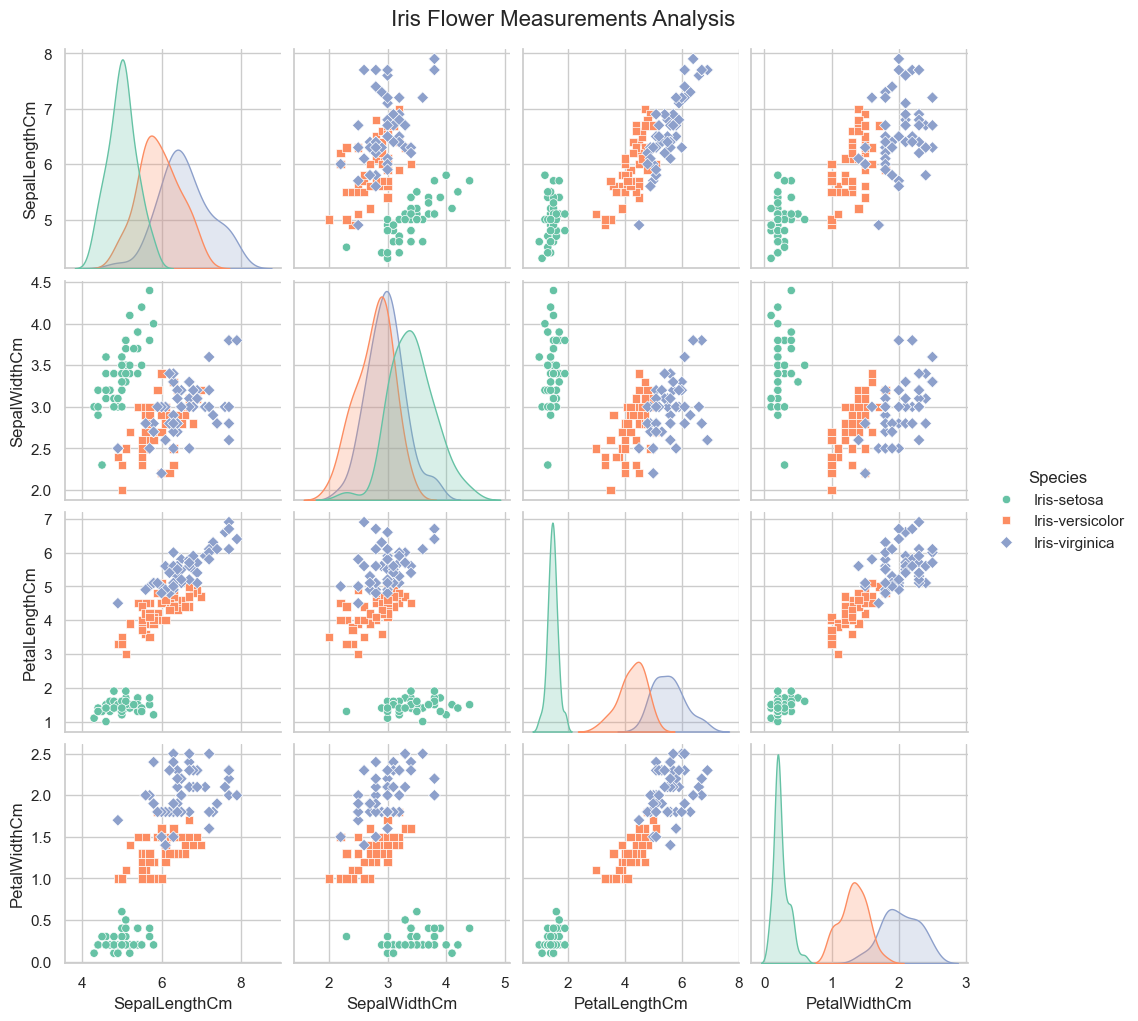

In [3]:
plt.figure(figsize=(10, 8))

# Created pairplot colored by the 'Species' column
sns.pairplot(iris_df, hue='Species', palette='Set2', markers=["o", "s", "D"])

plt.suptitle("Iris Flower Measurements Analysis", y=1.02, fontsize=16)
plt.show()

In [9]:
#Separating features and target [measurements - species]
tgt_name = 'Species'
flower_features = iris_df.drop(columns=[tgt_name])
flower_labels = iris_df[tgt_name]

#Splitted data into 80%-20% training -testing (used often because of best result in every task)
trn_feat, tst_feat, trn_lbl, tst_lbl = train_test_split(
    flower_features, flower_labels, test_size=0.2, random_state=42
)

#Initializing and training the Random Forest Classifier
iris_engine = RandomForestClassifier(n_estimators=100, random_state=42)
iris_engine.fit(trn_feat, trn_lbl)

print("Iris Classification Engine is fully trained.")

Iris Classification Engine is fully trained.


In [10]:
# Make predictions on hidden test set created earlier
predictions = iris_engine.predict(tst_feat)

# Calculating Accuracy percentage
acc_score = accuracy_score(tst_lbl, predictions) * 100

print(f"Model Accuracy: {acc_score:.2f}%\n It is Toy Dataset.")
print("--- Detailed Classification Report ---")
print(classification_report(tst_lbl, predictions))

Model Accuracy: 100.00%
 It is Toy Dataset.
--- Detailed Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



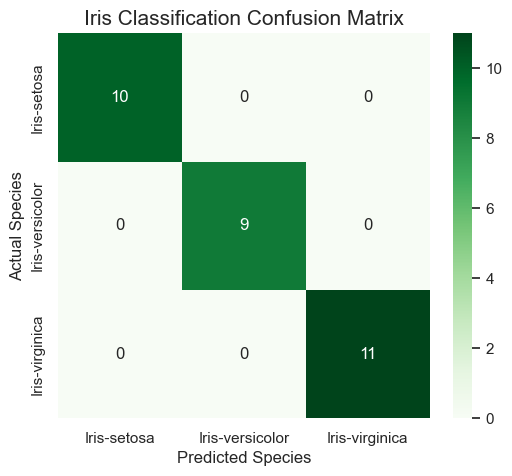

In [6]:
plt.figure(figsize=(6, 5))

# Generating confusion matrix
c_matrix = confusion_matrix(tst_lbl, predictions)
species_names = iris_engine.classes_

# Plotting using Seaborn's heatmap (good for visualization)
sns.heatmap(c_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=species_names, yticklabels=species_names)

plt.title('Iris Classification Confusion Matrix', fontsize=15)
plt.ylabel('Actual Species', fontsize=12)
plt.xlabel('Predicted Species', fontsize=12)
plt.show()

In [11]:
def predict_iris(sepal_len, sepal_wid, petal_len, petal_wid):
    """
    Takes 4 flower measurements and predicts the exact Iris species.
    """
    # Package the inputs into a format the model understands
    custom_flower = pd.DataFrame({
        'SepalLengthCm': [sepal_len],
        'SepalWidthCm': [sepal_wid],
        'PetalLengthCm': [petal_len],
        'PetalWidthCm': [petal_wid]
    })
    
    # Make the prediction
    guess = iris_engine.predict(custom_flower)
    return guess[0]

# --- Test it out! ---
# Feel free to change these numbers
sl, sw, pl, pw = 5.1, 3.5, 1.4, 0.2 

result = predict_iris(sl, sw, pl, pw)
print(f"Measurements: Sepal({sl}x{sw}), Petal({pl}x{pw})")
print(f"Prediction: This flower is an {result}!")

Measurements: Sepal(5.1x3.5), Petal(1.4x0.2)
Prediction: This flower is an Iris-setosa!
